Đã tải dữ liệu thành công! Kích thước: (20000, 13)
--- MA TRẬN TƯƠNG QUAN ---
                  student_id       age  study_hours  class_attendance  \
student_id          1.000000 -0.002574     0.002116          0.001128   
age                -0.002574  1.000000     0.002955          0.008449   
study_hours         0.002116  0.002955     1.000000         -0.001645   
class_attendance    0.001128  0.008449    -0.001645          1.000000   
sleep_hours        -0.000560 -0.000385    -0.004533          0.007187   
exam_score          0.003269  0.006522     0.717788          0.308850   

                  sleep_hours  exam_score  
student_id          -0.000560    0.003269  
age                 -0.000385    0.006522  
study_hours         -0.004533    0.717788  
class_attendance     0.007187    0.308850  
sleep_hours          1.000000    0.133222  
exam_score           0.133222    1.000000  


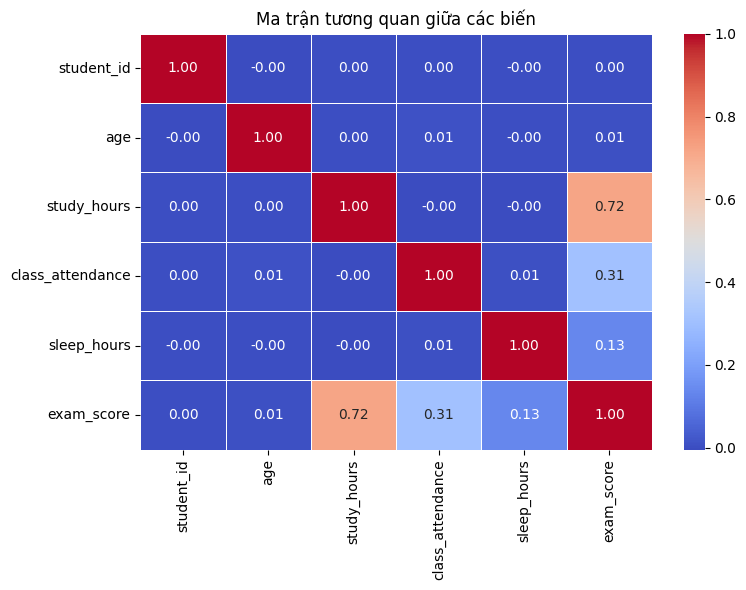

--- MỨC ĐỘ TƯƠNG QUAN VỚI EXAM SCORE ---
exam_score          1.000000
study_hours         0.717788
class_attendance    0.308850
sleep_hours         0.133222
age                 0.006522
student_id          0.003269
Name: exam_score, dtype: float64


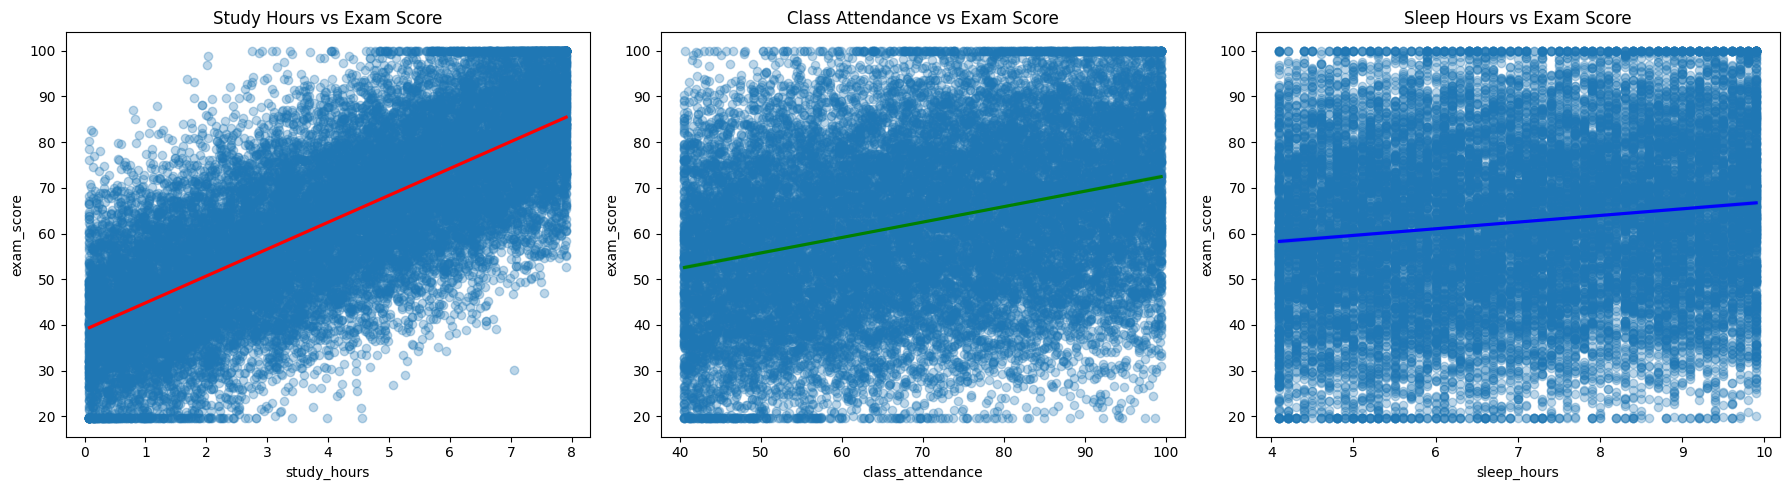

Đã lưu tất cả các biểu đồ vào thư mục result thành công!


In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Đường dẫn đến đúng vị trí file vừa tải lên
DATA_PATH = "/Exam_Score_Prediction.csv"
RESULT_DIR = os.path.join(".", "result")
os.makedirs(RESULT_DIR, exist_ok=True)

# 2. Đọc dữ liệu
df = pd.read_csv(DATA_PATH)
print(f"Đã tải dữ liệu thành công! Kích thước: {df.shape}")

# 3. Tính toán ma trận tương quan
corr = df.select_dtypes(include='number').corr()
print("--- MA TRẬN TƯƠNG QUAN ---")
print(corr)

# 4. Vẽ Heatmap và lưu ảnh
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Ma trận tương quan giữa các biến")
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'fig1_correlation_heatmap.png'), dpi=300)
plt.show()

# 5. Sắp xếp mức độ tương quan với exam_score
score_corr = corr['exam_score'].sort_values(ascending=False)
print("--- MỨC ĐỘ TƯƠNG QUAN VỚI EXAM SCORE ---")
print(score_corr)

# 6. Vẽ biểu đồ kiểm chứng các yếu tố chính và lưu ảnh
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.regplot(data=df, x='study_hours', y='exam_score', ax=axes[0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title('Study Hours vs Exam Score')

sns.regplot(data=df, x='class_attendance', y='exam_score', ax=axes[1], scatter_kws={'alpha':0.3}, line_kws={'color':'green'})
axes[1].set_title('Class Attendance vs Exam Score')

sns.regplot(data=df, x='sleep_hours', y='exam_score', ax=axes[2], scatter_kws={'alpha':0.3}, line_kws={'color':'blue'})
axes[2].set_title('Sleep Hours vs Exam Score')

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'fig2_verification_plots.png'), dpi=300)
plt.show()
print("Đã lưu tất cả các biểu đồ vào thư mục result thành công!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')